<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Tree_of_Lithography_Technologies_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 111ms


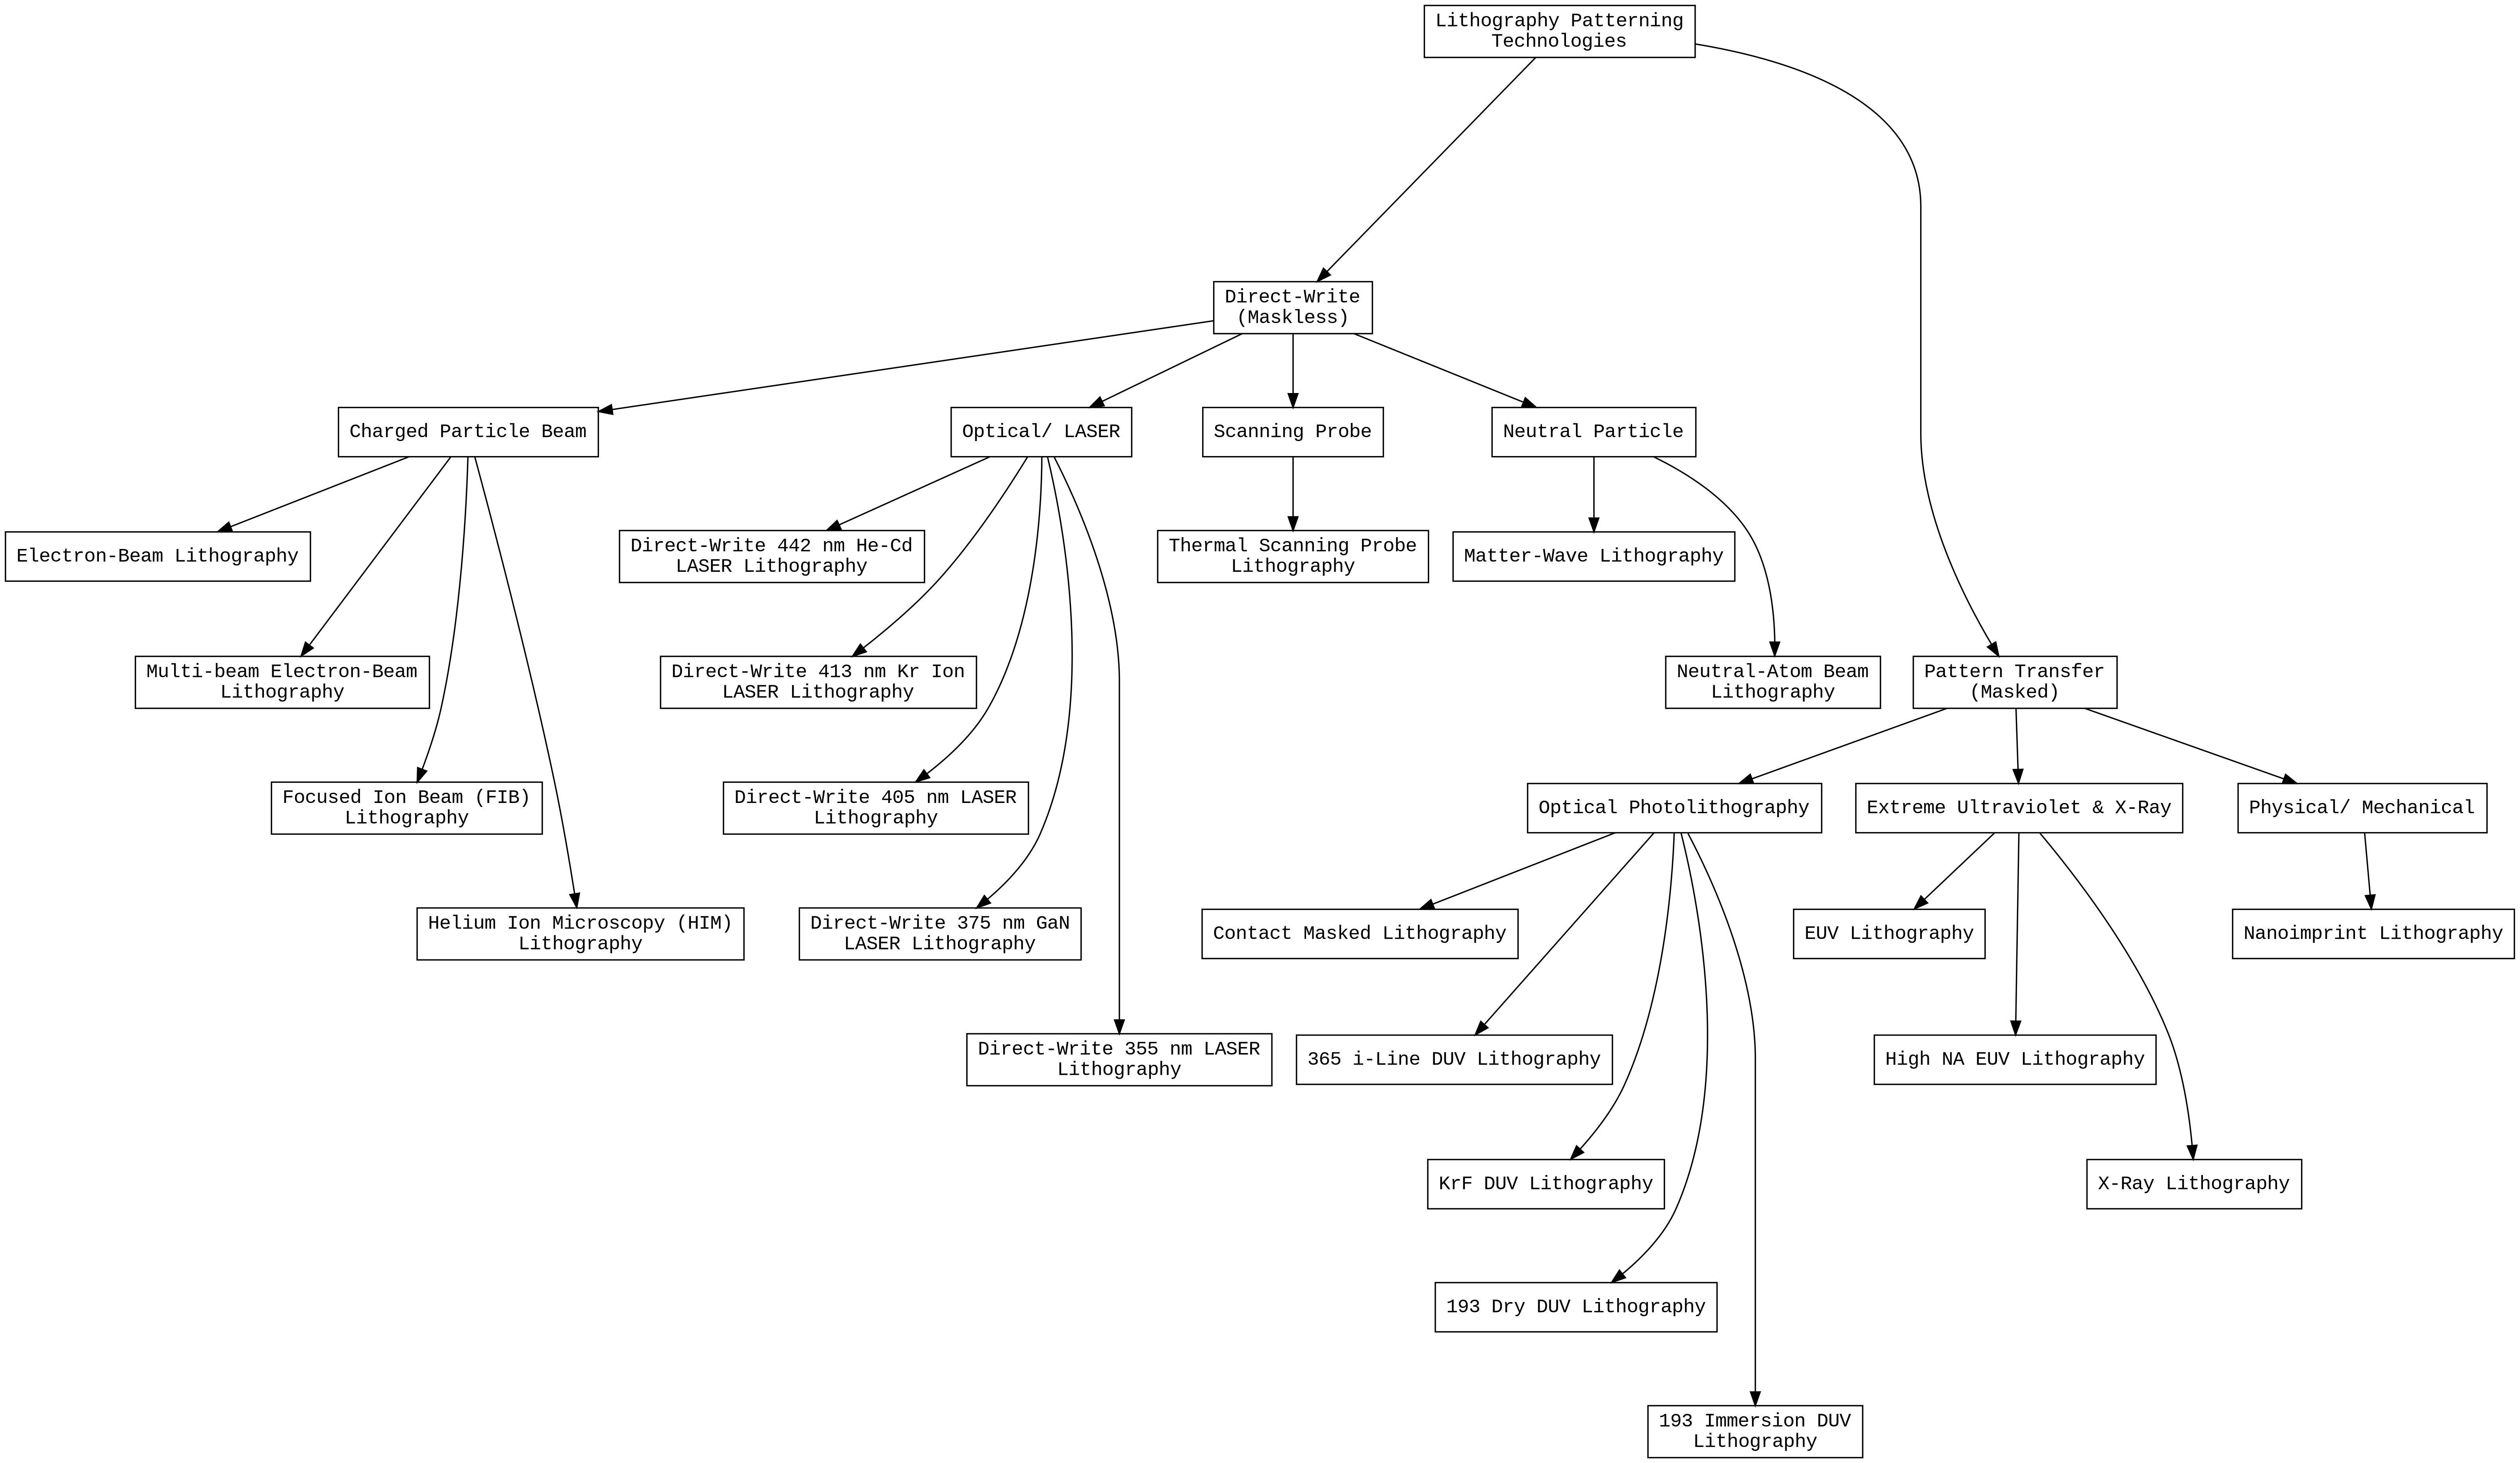

In [4]:
!uv pip install graphviz ipython

"""This script constructs a directed lithography classification graph and renders it as an in-memory downloadable object.

The graph avoids orthogonal edges and maintains an absolute monochrome aesthetic. Control parameters
defined at the module level dictate the precise font, resolution, and vertical spacing characteristics.
The script applies a hard character limit to each graphical node, cascades primary branches, and stretches
the diagram vertically. The output displays an interactive button permitting users to retrieve the image.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 27
RANK_SEPARATION = "0.75"     # Adjusts the global vertical stretch between all hierarchical ranks
BRANCH_STAGGER_STEP = 3      # Multiplies the vertical drop distance between primary root branches

def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, hyphenating oversized strings.

    Args:
        text: The original string input.
        max_width: The maximum allowable characters per line.

    Returns:
        A formatted string featuring newline characters at proper intervals.
    """
    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)

def build_lithography_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining lithography classifications."""
    tree = graphviz.Digraph(format='png')

    tree.attr(dpi=GRAPH_DPI, splines=EDGE_ROUTING, bgcolor=BACKGROUND_COLOR, rankdir=RANK_DIRECTION, ranksep=RANK_SEPARATION)
    tree.attr('node', shape=NODE_SHAPE, style='solid', color=FOREGROUND_COLOR, fontcolor=FOREGROUND_COLOR, fontname=NODE_FONT)
    tree.attr('edge', color=FOREGROUND_COLOR, arrowhead='normal')

    tree.node('Root', wrap_text('Lithography Patterning Technologies'))

    def add_staggered_leaves(parent_id: str, leaves: list) -> None:
        """Helper function to attach leaf nodes and stagger them vertically."""
        for idx, leaf_text in enumerate(leaves):
            leaf_id = f'{parent_id}_L_{idx}'
            tree.node(leaf_id, wrap_text(leaf_text))
            tree.edge(parent_id, leaf_id, minlen=str(idx + 1))

    # Primary Branches
    tree.node('Maskless', wrap_text('Direct-Write\n(Maskless)'))
    tree.edge('Root', 'Maskless', minlen=str(1 * BRANCH_STAGGER_STEP))

    tree.node('Masked', wrap_text('Pattern Transfer\n(Masked)'))
    tree.edge('Root', 'Masked', minlen=str(2 * BRANCH_STAGGER_STEP))

    # Maskless Sub-branches
    tree.node('ML_CP', wrap_text('Charged Particle Beam'))
    tree.edge('Maskless', 'ML_CP')
    add_staggered_leaves('ML_CP', [
        'Electron-Beam Lithography',
        'Multi-beam Electron-Beam Lithography',
        'Focused Ion Beam (FIB) Lithography',
        'Helium Ion Microscopy (HIM) Lithography'
    ])

    tree.node('ML_Opt', wrap_text('Optical/ LASER'))
    tree.edge('Maskless', 'ML_Opt')
    add_staggered_leaves('ML_Opt', [
        'Direct-Write 442 nm He-Cd LASER Lithography',
        'Direct-Write 413 nm Kr Ion LASER Lithography',
        'Direct-Write 405 nm LASER Lithography',
        'Direct-Write 375 nm GaN LASER Lithography',
        'Direct-Write 355 nm LASER Lithography'
    ])

    tree.node('ML_Probe', wrap_text('Scanning Probe'))
    tree.edge('Maskless', 'ML_Probe')
    add_staggered_leaves('ML_Probe', [
        'Thermal Scanning Probe Lithography'
    ])

    tree.node('ML_Neut', wrap_text('Neutral Particle'))
    tree.edge('Maskless', 'ML_Neut')
    add_staggered_leaves('ML_Neut', [
        'Matter-Wave Lithography',
        'Neutral-Atom Beam Lithography'
    ])

    # Masked Sub-branches
    tree.node('M_Photo', wrap_text('Optical Photolithography'))
    tree.edge('Masked', 'M_Photo')
    add_staggered_leaves('M_Photo', [
        'Contact Masked Lithography',
        '365 i-Line DUV Lithography',
        'KrF DUV Lithography',
        '193 Dry DUV Lithography',
        '193 Immersion DUV Lithography'
    ])

    tree.node('M_Adv', wrap_text('Extreme Ultraviolet & X-Ray'))
    tree.edge('Masked', 'M_Adv')
    add_staggered_leaves('M_Adv', [
        'EUV Lithography',
        'High NA EUV Lithography',
        'X-Ray Lithography'
    ])

    tree.node('M_Mech', wrap_text('Physical/ Mechanical'))
    tree.edge('Masked', 'M_Mech')
    add_staggered_leaves('M_Mech', [
        'Nanoimprint Lithography'
    ])

    return tree

def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')

    display(Image(data=binary_png))

    encoded_image = base64.b64encode(binary_png).decode('utf-8')

if __name__ == '__main__':
    lithography_tree = build_lithography_tree()
    display_and_generate_download(lithography_tree)